<a href="https://colab.research.google.com/github/Devadeth-cmyk/E-LMS/blob/main/fake_or_real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix


In [66]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [67]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#Read Data

In [68]:
filepath = '/content/drive/MyDrive/AI ML/Datasets/Fake.csv'
df_fake  = pd.read_csv(filepath)
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


#EDA

In [69]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [70]:
# Missing value checking
print('Missing values in df_fake:')
display(df_fake.isnull().sum())

Missing values in df_fake:


,0
title,0
text,0
subject,0
date,0


##Duplicate check

In [71]:
# Duplicate value check
df_fake.duplicated().sum()

np.int64(3)

In [72]:
#Removing duplicates
df_fake.drop_duplicates(inplace=True)

In [73]:
# Duplicate value check
df_fake.duplicated().sum()

np.int64(0)

#Preprocessing

##Lowercasing

In [74]:
# Combine 'title' and 'text' columns for preprocessing
df_fake['full_text'] = df_fake['title'] + ' ' + df_fake['text']

# Function to remove punctuation and convert to lowercase
def clean_text(text):
    text = str(text).lower()
    text = ''.join([char for char in text if char not in string.punctuation]) # Remove punctuation
    return text

df_fake['cleaned_text'] = df_fake['full_text'].apply(clean_text)
display(df_fake[['full_text', 'cleaned_text']].head())

,full_text,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends out embarrassing new year’...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes an internet joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump is so obsessed he even has obama’s name...
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis just called out donald trump dur...


##Tokenization

In [75]:
# Tokenization
def tokenize_text(text):
    return nltk.word_tokenize(text)

df_fake['tokenized_text'] = df_fake['cleaned_text'].apply(tokenize_text)
display(df_fake[['cleaned_text', 'tokenized_text']].head())

,cleaned_text,tokenized_text
0,donald trump sends out embarrassing new year’...,"[donald, trump, sends, out, embarrassing, new,..."
1,drunk bragging trump staffer started russian ...,"[drunk, bragging, trump, staffer, started, rus..."
2,sheriff david clarke becomes an internet joke...,"[sheriff, david, clarke, becomes, an, internet..."
3,trump is so obsessed he even has obama’s name...,"[trump, is, so, obsessed, he, even, has, obama..."
4,pope francis just called out donald trump dur...,"[pope, francis, just, called, out, donald, tru..."


##Stop word removal

In [76]:
# Stopword Removal
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df_fake['text_without_stopwords'] = df_fake['tokenized_text'].apply(remove_stopwords)
display(df_fake[['tokenized_text', 'text_without_stopwords']].head())

,tokenized_text,text_without_stopwords
0,"[donald, trump, sends, out, embarrassing, new,...","[donald, trump, sends, embarrassing, new, year..."
1,"[drunk, bragging, trump, staffer, started, rus...","[drunk, bragging, trump, staffer, started, rus..."
2,"[sheriff, david, clarke, becomes, an, internet...","[sheriff, david, clarke, becomes, internet, jo..."
3,"[trump, is, so, obsessed, he, even, has, obama...","[trump, obsessed, even, obama, ’, name, coded,..."
4,"[pope, francis, just, called, out, donald, tru...","[pope, francis, called, donald, trump, christm..."


##Lemmatization

In [77]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df_fake['lemmatized_text'] = df_fake['text_without_stopwords'].apply(lemmatize_text)
display(df_fake[['text_without_stopwords', 'lemmatized_text']].head())

,text_without_stopwords,lemmatized_text
0,"[donald, trump, sends, embarrassing, new, year...","[donald, trump, sends, embarrassing, new, year..."
1,"[drunk, bragging, trump, staffer, started, rus...","[drunk, bragging, trump, staffer, started, rus..."
2,"[sheriff, david, clarke, becomes, internet, jo...","[sheriff, david, clarke, becomes, internet, jo..."
3,"[trump, obsessed, even, obama, ’, name, coded,...","[trump, obsessed, even, obama, ’, name, coded,..."
4,"[pope, francis, called, donald, trump, christm...","[pope, francis, called, donald, trump, christm..."


In [78]:
# Join the lemmatized tokens back into a string
df_fake['processed_text'] = df_fake['lemmatized_text'].apply(lambda x: ' '.join(x))
display(df_fake[['full_text', 'processed_text']].head())

,full_text,processed_text
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year ’ eve...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama ’ name coded website...
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...


##TF-IDF

In [79]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features

# Fit and transform the processed text
X_tfidf = tfidf_vectorizer.fit_transform(df_fake['processed_text'])
display(X_tfidf.shape)

(23478, 5000)

In [80]:
# Prepare the target variable
le = LabelEncoder()
y = le.fit_transform(df_fake['subject'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify = y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (18782, 5000)
X_test shape: (4696, 5000)
y_train shape: (18782,)
y_test shape: (4696,)


#Model building

##Logistic Regression

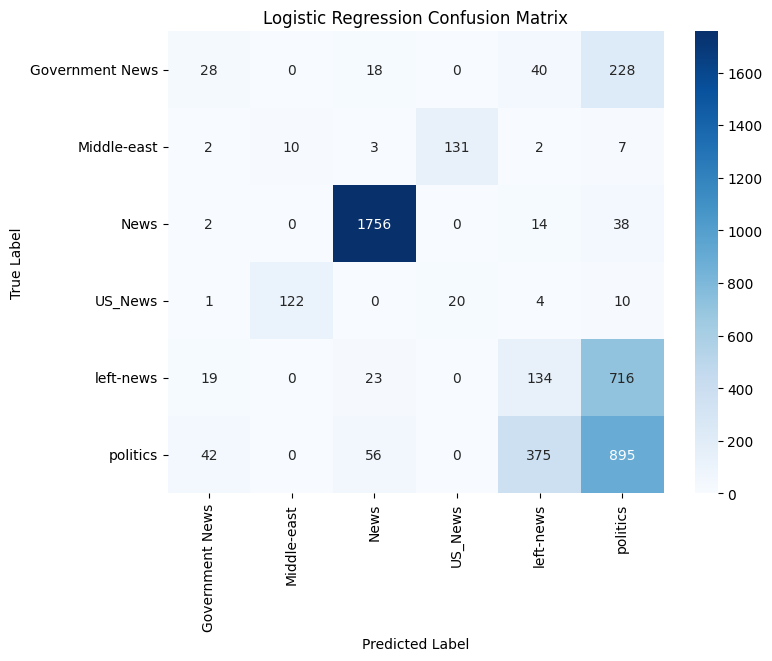

In [93]:
# Logistic regression model
log_reg = LogisticRegression(max_iter = 1000)

# train the model
log_reg.fit(X_train, y_train)

# make predictions on X_test
y_pred_log_reg = log_reg.predict(X_test)


In [92]:
#Evaluation
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg, average = 'weighted')
recall_log_reg = recall_score(y_test, y_pred_log_reg, average = 'weighted')
f1_log_reg = f1_score(y_test, y_pred_log_reg, average = 'weighted')
#roc-auc
y_proba_log_reg = log_reg.predict_proba(X_test)
roc_auc_log_reg = roc_auc_score(y_test, y_proba_log_reg, multi_class='ovr', average='weighted')

print(f"Logistic Regression Accuracy: {acc_log_reg:.4f}")
print(f"Logistic Regression Precision: {precision_log_reg:.4f}")
print(f"Logistic Regression Recall: {recall_log_reg:.4f}")
print(f"Logistic Regression F1-Score: {f1_log_reg:.4f}")
print(f"Logistic Regression ROC AUC: {roc_auc_log_reg:.4f}")

Logistic Regression Accuracy: 0.6054
Logistic Regression Precision: 0.5739
Logistic Regression Recall: 0.6054
Logistic Regression F1-Score: 0.5798
Logistic Regression ROC AUC: 0.8768


##Decision Tree

Decision Tree Accuracy: 0.4764
Decision Tree Precision: 0.4917
Decision Tree Recall: 0.4764
Decision Tree F1-Score: 0.4824
Decision Tree ROC AUC: 0.6840


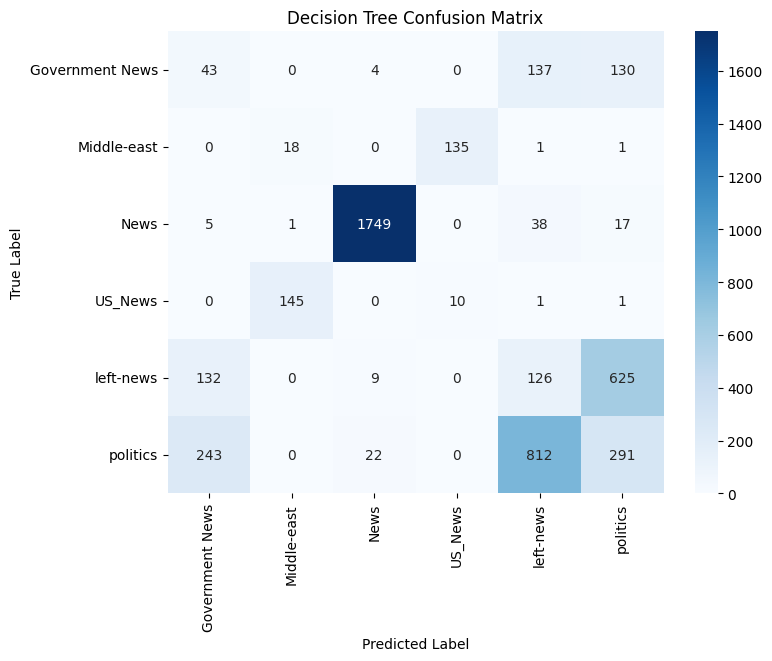

In [95]:
# Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on X_test
y_pred_dtc = dtc.predict(X_test)

# Evaluation
acc_dtc = accuracy_score(y_test, y_pred_dtc)
precision_dtc = precision_score(y_test, y_pred_dtc, average='weighted', zero_division=0)
recall_dtc = recall_score(y_test, y_pred_dtc, average='weighted', zero_division=0)
f1_dtc = f1_score(y_test, y_pred_dtc, average='weighted', zero_division=0)

print(f"Decision Tree Accuracy: {acc_dtc:.4f}")
print(f"Decision Tree Precision: {precision_dtc:.4f}")
print(f"Decision Tree Recall: {recall_dtc:.4f}")
print(f"Decision Tree F1-Score: {f1_dtc:.4f}")

try:
    y_proba_dtc = dtc.predict_proba(X_test)
    roc_auc_dtc = roc_auc_score(y_test, y_proba_dtc, multi_class='ovr', average='weighted')
    print(f"Decision Tree ROC AUC: {roc_auc_dtc:.4f}")
except AttributeError:
    print("Decision Tree does not support predict_proba for ROC AUC calculation. Skipping.")



## AdaBoost Classifier

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (Decision Tree) Accuracy: 0.6780
AdaBoost (Decision Tree) Precision: 0.5722
AdaBoost (Decision Tree) Recall: 0.6780
AdaBoost (Decision Tree) F1-Score: 0.5891
AdaBoost (Decision Tree) ROC AUC: 0.8612


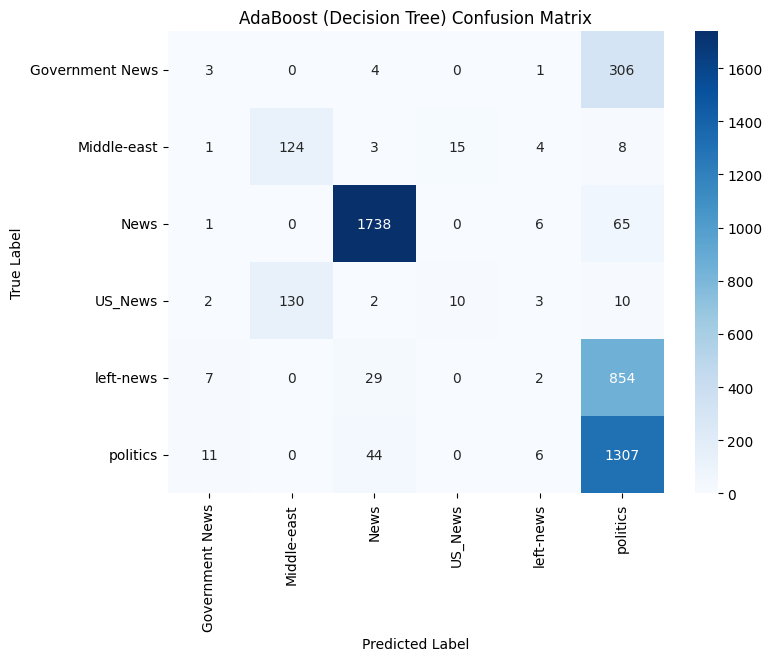

In [97]:
# AdaBoost Classifier

base_estimator_dt = DecisionTreeClassifier(max_depth=1)
adaboost_clf_dt = AdaBoostClassifier(estimator=base_estimator_dt, n_estimators=100, random_state=42, algorithm='SAMME')

# Train the model
adaboost_clf_dt.fit(X_train, y_train)

# Make predictions on X_test
y_pred_ada_dt = adaboost_clf_dt.predict(X_test)

# Evaluation
acc_ada_dt = accuracy_score(y_test, y_pred_ada_dt)
precision_ada_dt = precision_score(y_test, y_pred_ada_dt, average='weighted', zero_division=0)
recall_ada_dt = recall_score(y_test, y_pred_ada_dt, average='weighted', zero_division=0)
f1_ada_dt = f1_score(y_test, y_pred_ada_dt, average='weighted', zero_division=0)

print(f"AdaBoost (Decision Tree) Accuracy: {acc_ada_dt:.4f}")
print(f"AdaBoost (Decision Tree) Precision: {precision_ada_dt:.4f}")
print(f"AdaBoost (Decision Tree) Recall: {recall_ada_dt:.4f}")
print(f"AdaBoost (Decision Tree) F1-Score: {f1_ada_dt:.4f}")

try:
    y_proba_ada_dt = adaboost_clf_dt.predict_proba(X_test)
    roc_auc_ada_dt = roc_auc_score(y_test, y_proba_ada_dt, multi_class='ovr', average='weighted')
    print(f"AdaBoost (Decision Tree) ROC AUC: {roc_auc_ada_dt:.4f}")
except AttributeError:
    print("AdaBoost (Decision Tree) does not support predict_proba for ROC AUC calculation. Skipping.")


#Error Analysis & Model Interpretation

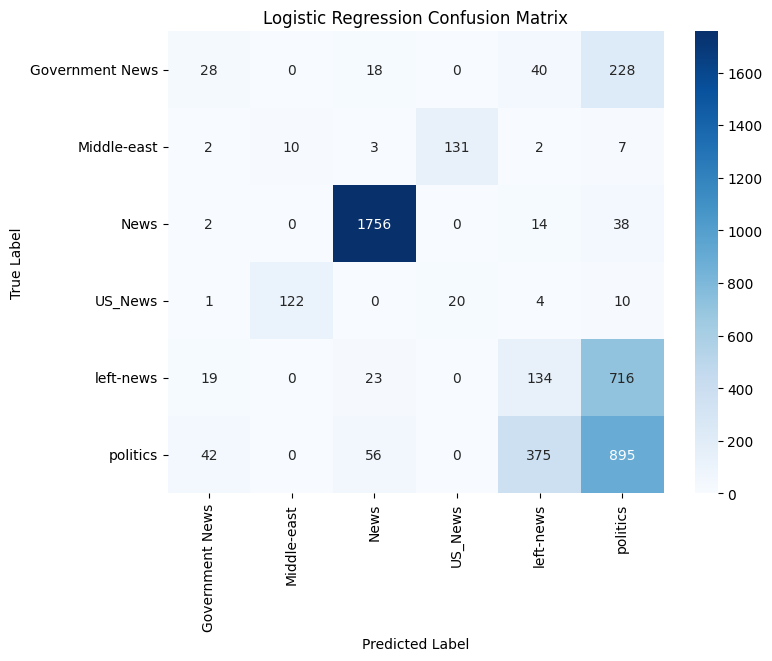

In [98]:
#Logistic Regression - Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

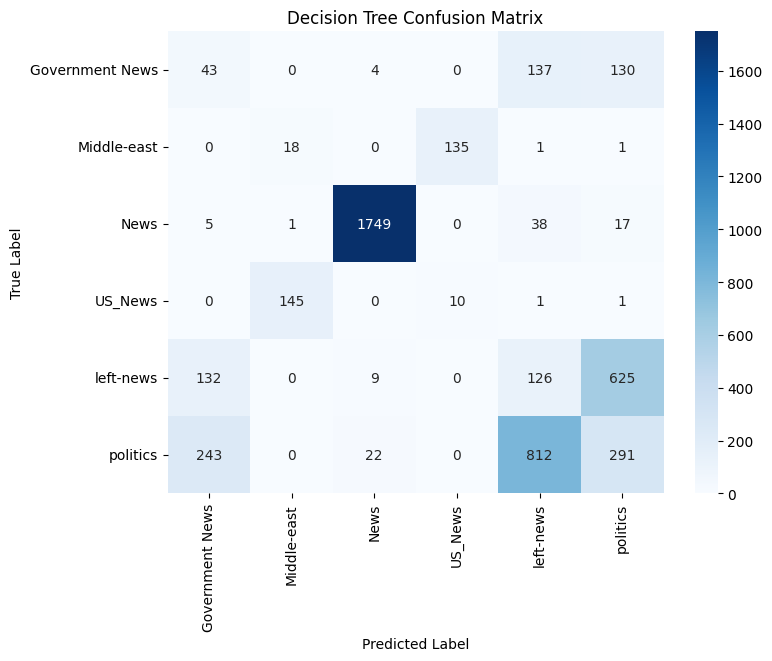

In [99]:
# Decision Tree - Confusion Matrix
cm_dtc = confusion_matrix(y_test, y_pred_dtc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

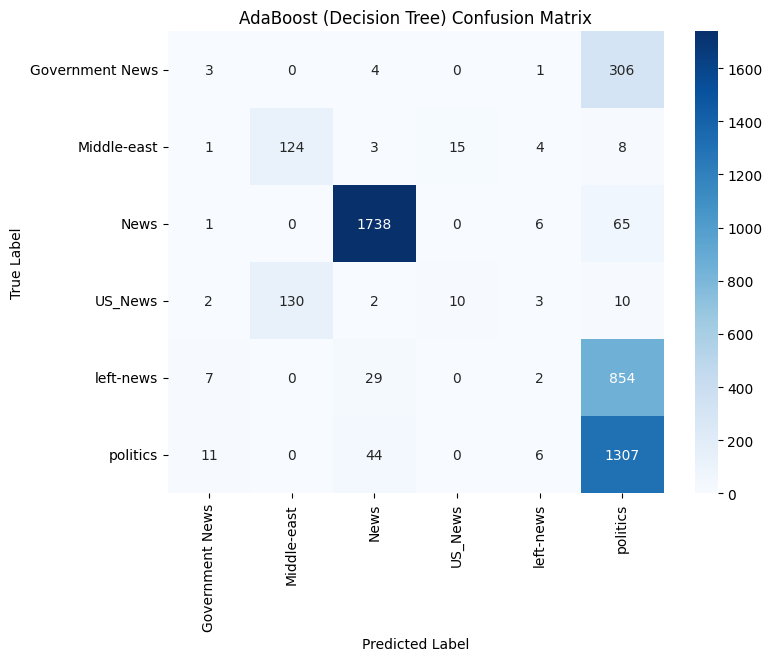

In [100]:
# Confusion Matrix - AdaBoost
cm_ada_dt = confusion_matrix(y_test, y_pred_ada_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ada_dt, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('AdaBoost (Decision Tree) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Strealit Deployment

In [101]:
import pickle

In [102]:
#saving the model with the best performance as a .pkl file, here it is adaboost model

with open('adaboost_model.pkl', 'wb') as file:
  pickle.dump(adaboost_clf_dt, file)